# FEM Dataset Lookup in SAX Models

::::{admonition} Required extras
:class: tip

This notebook needs the `models` extra:

```bash
uv add "qpdk[models]"
# or, from a checkout of this repository:
uv sync --extra models
# or with pip:
pip install "qpdk[models]"
```

See the {ref}`extras reference <notebook-extras>` for what each extra installs.
::::

Circuit models of superconducting layouts need electrostatic quantities such as
capacitance matrices, which for realistic geometries come from finite-element
(FEM) solvers {cite:p}`jinFiniteElementMethod2014`. One solve takes minutes to
hours, far too slow to call inside a circuit simulation or an optimisation loop.
So a sweep over the design parameters is solved once, stored as a dataset, and
the circuit model interpolates between the stored points.

::::{only} html
:::{mermaid}
flowchart LR
    A["FEM solve<br/>per geometry"] --> B["Sweep over<br/>parameter grid"]
    B --> C["Parquet parts or<br/>Delta table + metadata"]
    C --> D["Dataset.grid<br/>dense array"]
    D --> E["GridInterpolator<br/>jittable lookup"]
    E --> F["SAX model"]
:::
::::

::::{only} typst or typstpdf
A FEM solve per geometry is swept over a parameter grid and stored as Parquet parts or a Delta table carrying its metadata; the dataset is arranged into a dense grid, wrapped in a jittable interpolator, and called from a SAX model.
::::

{mod}`qpdk.models.datasets` stores the results as a long-format
[Polars](https://pola.rs) table with one row per matrix entry. Each Parquet
file (or the Delta table schema) also carries the dataset metadata: units,
terminal and ground conventions, whether the data is synthetic, and free-form
provenance such as the layer stack and solver. A file is therefore
self-describing, and the parameter grid is read off the data rather than
declared separately. Curated datasets ship in the package as Parquet parts in
Git LFS; shared, growing datasets can live in a Delta Lake table on a cloud
bucket.

This notebook follows generation, storage, lazy queries and JAX interpolation,
then uses the capacitance lookup in a SAX model.
Run `uv run --script notebooks/src/fem_dataset_lookup.py` with Git LFS installed
to use the pinned QPDK revision and fetch its bundled results automatically.

The bundled data comes from Palace electrostatic solves of the actual QPDK
metal polygons, including their short leads, as perfect conductor sheets on
silicon. A separate coplanar ground frame surrounds the device. The geometry
and mesh settings travel with the data. It covers lengths 40–120 µm, widths
5–20 µm and gaps 4–10 µm; these results apply to that geometry and stack.


In [1]:
import sys

if "google.colab" in sys.modules:
    import subprocess

    print("Running in Google Colab. Installing QPDK...")
    subprocess.check_call(["apt-get", "install", "-y", "-qq", "git-lfs"])
    subprocess.check_call(["git", "lfs", "install", "--skip-repo"])
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "qpdk[models] @ git+https://github.com/jackgdsf/quantum-rf-pdk.git@c5dc19af770c11f61e6dffb5e233726e0ebb2524",
        "matplotlib-inline",
    ])

In [2]:
import subprocess
import time
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import sax
import xarray as xr
from matplotlib.colors import LogNorm
from matplotlib_inline.backend_inline import set_matplotlib_formats

from qpdk import logger
from qpdk.colormaps import QPDK
from qpdk.config import PATH
from qpdk.models.capacitor import plate_capacitor
from qpdk.models.constants import DEFAULT_FREQUENCY
from qpdk.models.couplers import (
    cpw_coupling_model,
    cpw_cpw_coupling_capacitance,
    cpw_cpw_coupling_capacitance_per_length_analytical,
)
from qpdk.models.cpw import cpw_z0_from_cross_section
from qpdk.models.datasets import (
    Dataset,
    GridInterpolator,
    capacitance_model,
    check_maxwell,
    maxwell_to_mutual,
)
from qpdk.models.datasets.generate import write
from qpdk.models.generic import capacitor
from qpdk.tech import coplanar_waveguide

set_matplotlib_formats("png", "svg")
for style_source in (PATH.repo / "docs" / "qpdk.mplstyle", "qpdk"):
    try:
        plt.style.use(style_source)
    except OSError:
        continue
    break

## Inspect the dataset

The metadata is read from the files and validated when the dataset opens. The
results table is a plain Polars frame with one row per matrix entry, so it can
be filtered and aggregated without loading anything into JAX.

In [3]:
dataset = Dataset("plate_capacitor_palace")
metadata = dataset.metadata
logger.info(f"{dataset!r}: synthetic={metadata.synthetic}")
logger.info(f"solver: {metadata.provenance['solver']}")
logger.info(f"extraction settings: {metadata.provenance['settings']}")
logger.info(f"terminals {metadata.terminals} w.r.t. {metadata.reference_ground!r}")
for axis in metadata.axes:
    logger.info(
        f"{axis.name} [{axis.unit}]: validated domain {axis.validated or 'grid span'}"
    )

In [4]:
dataset.table.head(8)

In [5]:
(
    dataset
    .scan()
    .filter(pl.col("row") != pl.col("col"))
    .group_by("gap")
    .agg(c_mutual_fF=(-pl.col("value")).mean() * 1e15)
    .sort("gap")
    .collect()
)

## Define a generation script

`qpdk/models/datasets/data/plate_capacitor.py` is a complete experiment: its `GRID`, `SETTINGS`,
metadata and `solve` function describe what to extract. Its inline dependencies
let `uv run --script` create the Python 3.12 environment required by gsim.
Copy the script beside the original in `qpdk/models/datasets/data/` and edit it for another dataset.

Meshing runs on the host, including when Palace uses `--sif`. Gmsh needs its native
libraries there; on Linux this includes `libGLU.so.1`. The container needs
a Palace binary with MPI support; select its executable with `--container-binary`.

Preview the full sweep or run it from a checkout:

```bash
uv run --script qpdk/models/datasets/data/plate_capacitor.py --dry-run
uv run --script qpdk/models/datasets/data/plate_capacitor.py --processes 4
# A local Palace container:
uv run --script qpdk/models/datasets/data/plate_capacitor.py --sif /path/to/palace.sif
```

The script builds a QPDK component. gsim meshes its electrodes with meshwell,
writes the configuration and runs Palace. Results carry their metadata; lookup
needs neither the generator nor the simulator. Generator scripts stay outside wheels.

In [6]:
small_grid = {"length": [40.0, 80.0], "width": [10.0], "gap": [4.0, 7.0, 10.0]}
output = Path("build/dataset-example/coarse")
generator_script = Path("qpdk/models/datasets/data/plate_capacitor.py")

## Run a small sweep and inspect its output

Copy the generator beside the original, replace `GRID` with `small_grid`, then run it with
`--output build/dataset-example/coarse`. For example, its grid definition becomes:

```python
GRID = {"length": [40.0, 80.0], "width": [10.0], "gap": [4.0, 7.0, 10.0]}
```

Set `RUN_PALACE=True` to execute the generator from a checkout. It runs the
grid defined in `generator_script`; point this path to your edited copy.
The default selects six existing Palace results and performs no new solves.
Both paths produce a self-describing table with four matrix entries and scalar diagnostics per solve.

In [7]:
RUN_PALACE = False

if RUN_PALACE:
    subprocess.run(  # ruff: ignore[subprocess-without-shell-equals-true]
        [
            "uv",
            "run",
            "--script",
            str(generator_script),
            "--output",
            str(output),
        ],
        check=True,
    )
    generated = Dataset(output)
else:
    selection = (
        dataset
        .scan()
        .filter(*(pl.col(axis).is_in(values) for axis, values in small_grid.items()))
        .collect()
    )
    generated = write(output, dataset.metadata, selection)
    logger.info("Selected six existing Palace solves; no simulator was run")
coarse = generated.grid("maxwell_capacitance", cross_section="cpw")
logger.info(f"Output: {generated.scan().select(pl.len()).collect().item()} rows")
logger.info(
    f"Dense grid: {coarse.values.shape}, terminals={generated.metadata.terminals}"
)
coarse_lookup = GridInterpolator(coarse)
logger.info(
    f"Small-sweep lookup at 60/10/7 µm [fF]:\n"
    f"{coarse_lookup(length=60.0, width=10.0, gap=7.0) * 1e15}"
)

2026-10-10 06:23:55.819 | INFO     | __main__:<module>:24 - Selected six existing Palace solves; no simulator was run


2026-10-10 06:23:55.832 | INFO     | __main__:<module>:26 - Output: 42 rows


2026-10-10 06:23:55.832 | INFO     | __main__:<module>:27 - Dense grid: (2, 1, 3, 2, 2), terminals=('o1', 'o2')


2026-10-10 06:23:56.199 | INFO     | __main__:<module>:31 - Small-sweep lookup at 60/10/7 µm [fF]:
[[10.89109106 -3.13697966]
 [-3.13697966 10.89350212]]


In [8]:
(
    generated
    .scan()
    .filter(pl.col("quantity") == "maxwell_capacitance")
    .group_by("length", "width", "gap", "status")
    .len(name="matrix_entries")
    .sort("length", "gap")
    .collect()
)

length,width,gap,status,matrix_entries
f64,f64,f64,str,u32
40.0,10.0,4.0,"""ok""",4
40.0,10.0,7.0,"""ok""",4
40.0,10.0,10.0,"""ok""",4
80.0,10.0,4.0,"""ok""",4
80.0,10.0,7.0,"""ok""",4
80.0,10.0,10.0,"""ok""",4


## Resume and extend a sweep

Rerun the generator after an interruption. Each geometry retains its inputs,
mesh, config, solver log and output. Completed matching runs are reused;
failed ones retry. Geometry, mesh, generator or runtime changes get a new run
directory. The published dataset is replaced only after the sweep succeeds.

Add `120.0` to the small script's length grid and rerun with the same
`--workdir`: six geometries are reused and three are added. Use `--output`
and `--workdir` to select locations; paths are relative to your current directory.

## Parallel sweeps

Both experiments accept `--shard INDEX --shards COUNT`. The longest axis is
split into disjoint rectangular grids, with unchanged solver inputs and run
identities. Workers write separate outputs and run directories; merging
checks provenance, coverage and successful results before publication.
Use a small array of longer shards, with no more tasks than points on the
longest axis. For the CPW grid:

```bash
generator=qpdk/models/datasets/data/cpw_coupling.py
sbatch --array=0-1 --cpus-per-task=4 qpdk/models/datasets/data/slurm_array.sh "$generator" \
  build/cpw-shards build/cpw-runs --sif /path/to/palace.sif
# After every task succeeds, pass each shard as a repeated option:
shards=()
for i in {0..1}; do shards+=(--merge-shards "build/cpw-shards/shard-$i"); done
uv run --script "$generator" "${shards[@]}" --output build/datasets/cpw_coupling_palace
```

Each task runs one solve at a time with four MPI ranks, one thread per rank.
Specify the array size with `--array`; `--cpus-per-task` sets MPI ranks per solve.

Without Slurm, run the entire script directly or use a local loop. This
sequential loop needs four cores; independent shard commands can also run
concurrently if each has its own four-core allocation:

```bash
generator=qpdk/models/datasets/data/cpw_coupling.py
export OMP_NUM_THREADS=1 OPENBLAS_NUM_THREADS=1 MKL_NUM_THREADS=1
shards=()
for i in {0..1}; do
  uv run --script "$generator" --shard "$i" --shards 2 --processes 4 \
    --output "build/cpw-shards/shard-$i" --workdir "build/cpw-runs/shard-$i"
  shards+=(--merge-shards "build/cpw-shards/shard-$i")
done
uv run --script "$generator" "${shards[@]}" --output build/datasets/cpw_coupling_palace
```

Keep the script, settings, runtime and array size fixed while resuming.
The reusable `partition_grid` and `merge` functions also work with other
experiment scripts and schedulers.

## Check mesh and domain sensitivity

Each result stores the worst terminal's linear-solver residual and iteration count,
plus Palace's energy-normalized recovered-flux FEM error indicator. The generator
rejects missing diagnostics or a linear solve that exceeds `SETTINGS.tolerance`.
Linear convergence alone does not establish mesh accuracy. The FEM indicator ranks
candidates for refinement; it is not a percentage error in capacitance.

A denser parameter grid cannot repair a coarse FEM mesh. In a copy of the
generator, select one geometry and vary the settings:

```python
from dataclasses import replace

GRID = {"length": [80.0], "width": [10.0], "gap": [7.0]}
SETTINGS = replace(SETTINGS, near_mesh=0.38, far_mesh=17.0, save_fields=True)
```

Reduce both near and far mesh sizes with separate output directories,
then increase `domain_pad` to 150 µm. Compare the Maxwell matrices and inspect
the saved fields in ParaView, especially near metal edges and gaps. Repeat
representative checks near the ends of any expanded geometry range.
For each quantity of interest, compare successive solves using
$|C_{\text{fine}}-C_{\text{coarse}}|/|C_{\text{fine}}|$, checking mesh and domain changes separately.

For the bundled extraction at 80/10/7 µm, the final mesh refinement changed
entries by at most 0.49%; enlarging the domain changed them by 0.19%. Across
the center and eight corners, these changes reached 0.87% and 0.36%. Four
held-out solves at width 10 µm differed from interpolation by at most 2.70%.
These checks do not establish a uniform accuracy bound for every geometry.

## Query a shared Delta table

Cloud datasets use the same interface. Select the quantity and variant before
collecting; `grid()` does this internally. Pin a version for reproducible models:

```python
shared = Dataset("gs://my-bucket/capacitors", delta=True, version=3)
rows = shared.scan().filter(
    pl.col("quantity") == "maxwell_capacitance",
    pl.col("cross_section") == "cpw",
).select("length", "gap", "value").collect()
lookup = GridInterpolator(shared.grid("maxwell_capacitance", cross_section="cpw"))
```

Scans stay lazy until `collect()`, allowing Polars to push filters and column
selection into storage. Only the selected interpolation grid becomes a dense
in-memory array. `dataset.table` explicitly loads and validates all rows.

## Look up a Maxwell capacitance matrix

For conductors $1, \dots, n$ at potentials $V_j$ above a reference ground, the
charges are linear in the potentials, $Q_i = \sum_j C_{ij} V_j$. The
*Maxwell* capacitance matrix $C$ is what an electrostatic FEM solver returns:
it is symmetric, its diagonal is positive, and its off-diagonal entries are
non-positive. The *mutual* capacitance between conductors $i \neq j$ is
$C^{\text{m}}_{ij} = -C_{ij}$, and the capacitance of conductor $i$ to ground
is the row sum $C^{\text{m}}_{ii} = \sum_j C_{ij}$. The mutual form is what
appears as branch capacitances in a lumped circuit, and the Maxwell form is the
capacitance matrix of circuit quantization
{cite:p}`voolIntroductionQuantumElectromagnetic2017`.
{func}`~qpdk.models.datasets.maxwell_to_mutual` converts between them, and
{func}`~qpdk.models.datasets.check_maxwell` raises if any property above is violated.

Between the solved points the lookup is multilinear: inside the grid cell
containing a query, the result is a weighted mean of the $2^n$ cell corners,
with weights that are products of the 1D linear weights along each axis
{cite:p}`weiserNotePiecewiseLinear1988`. It reproduces the data exactly at grid
points, is continuous everywhere, and needs no tuning. Outside the validated
domain there is no data to weigh, so the result is NaN.

![Rectilinear grid of solved points; a query inside a cell is a weighted mean of the cell corners, a query outside the grid returns NaN](figures/fem-dataset-lookup.svg)

{meth}`~qpdk.models.datasets.Dataset.grid` arranges the table into a dense
`(length, width, gap, 2, 2)` array and raises if a grid point is missing or
failed. Discrete variants such as the cross-section are chosen explicitly
here and never interpolated. {class}`~qpdk.models.datasets.GridInterpolator` wraps
{class}`jax.scipy.interpolate.RegularGridInterpolator` and holds plain JAX
arrays, so it works inside {func}`jax.jit`, {func}`jax.vmap`, and
{func}`jax.grad`.

In [9]:
grid = dataset.grid("maxwell_capacitance", cross_section="cpw")
c_maxwell = GridInterpolator(grid)
logger.info(repr(c_maxwell))

C = c_maxwell(length=100.0, width=10.0, gap=5.0)
logger.info(f"Maxwell matrix [fF]:\n{C * 1e15}")
logger.info(f"Mutual matrix [fF]:\n{maxwell_to_mutual(C) * 1e15}")
check_maxwell(C)  # raises NonPhysicalMatrixError if C is not physical

Outside the validated domain the lookup returns NaN. {func}`sax.interpolate_xarray`
clamps to the nearest edge instead, which hides an out-of-range design.

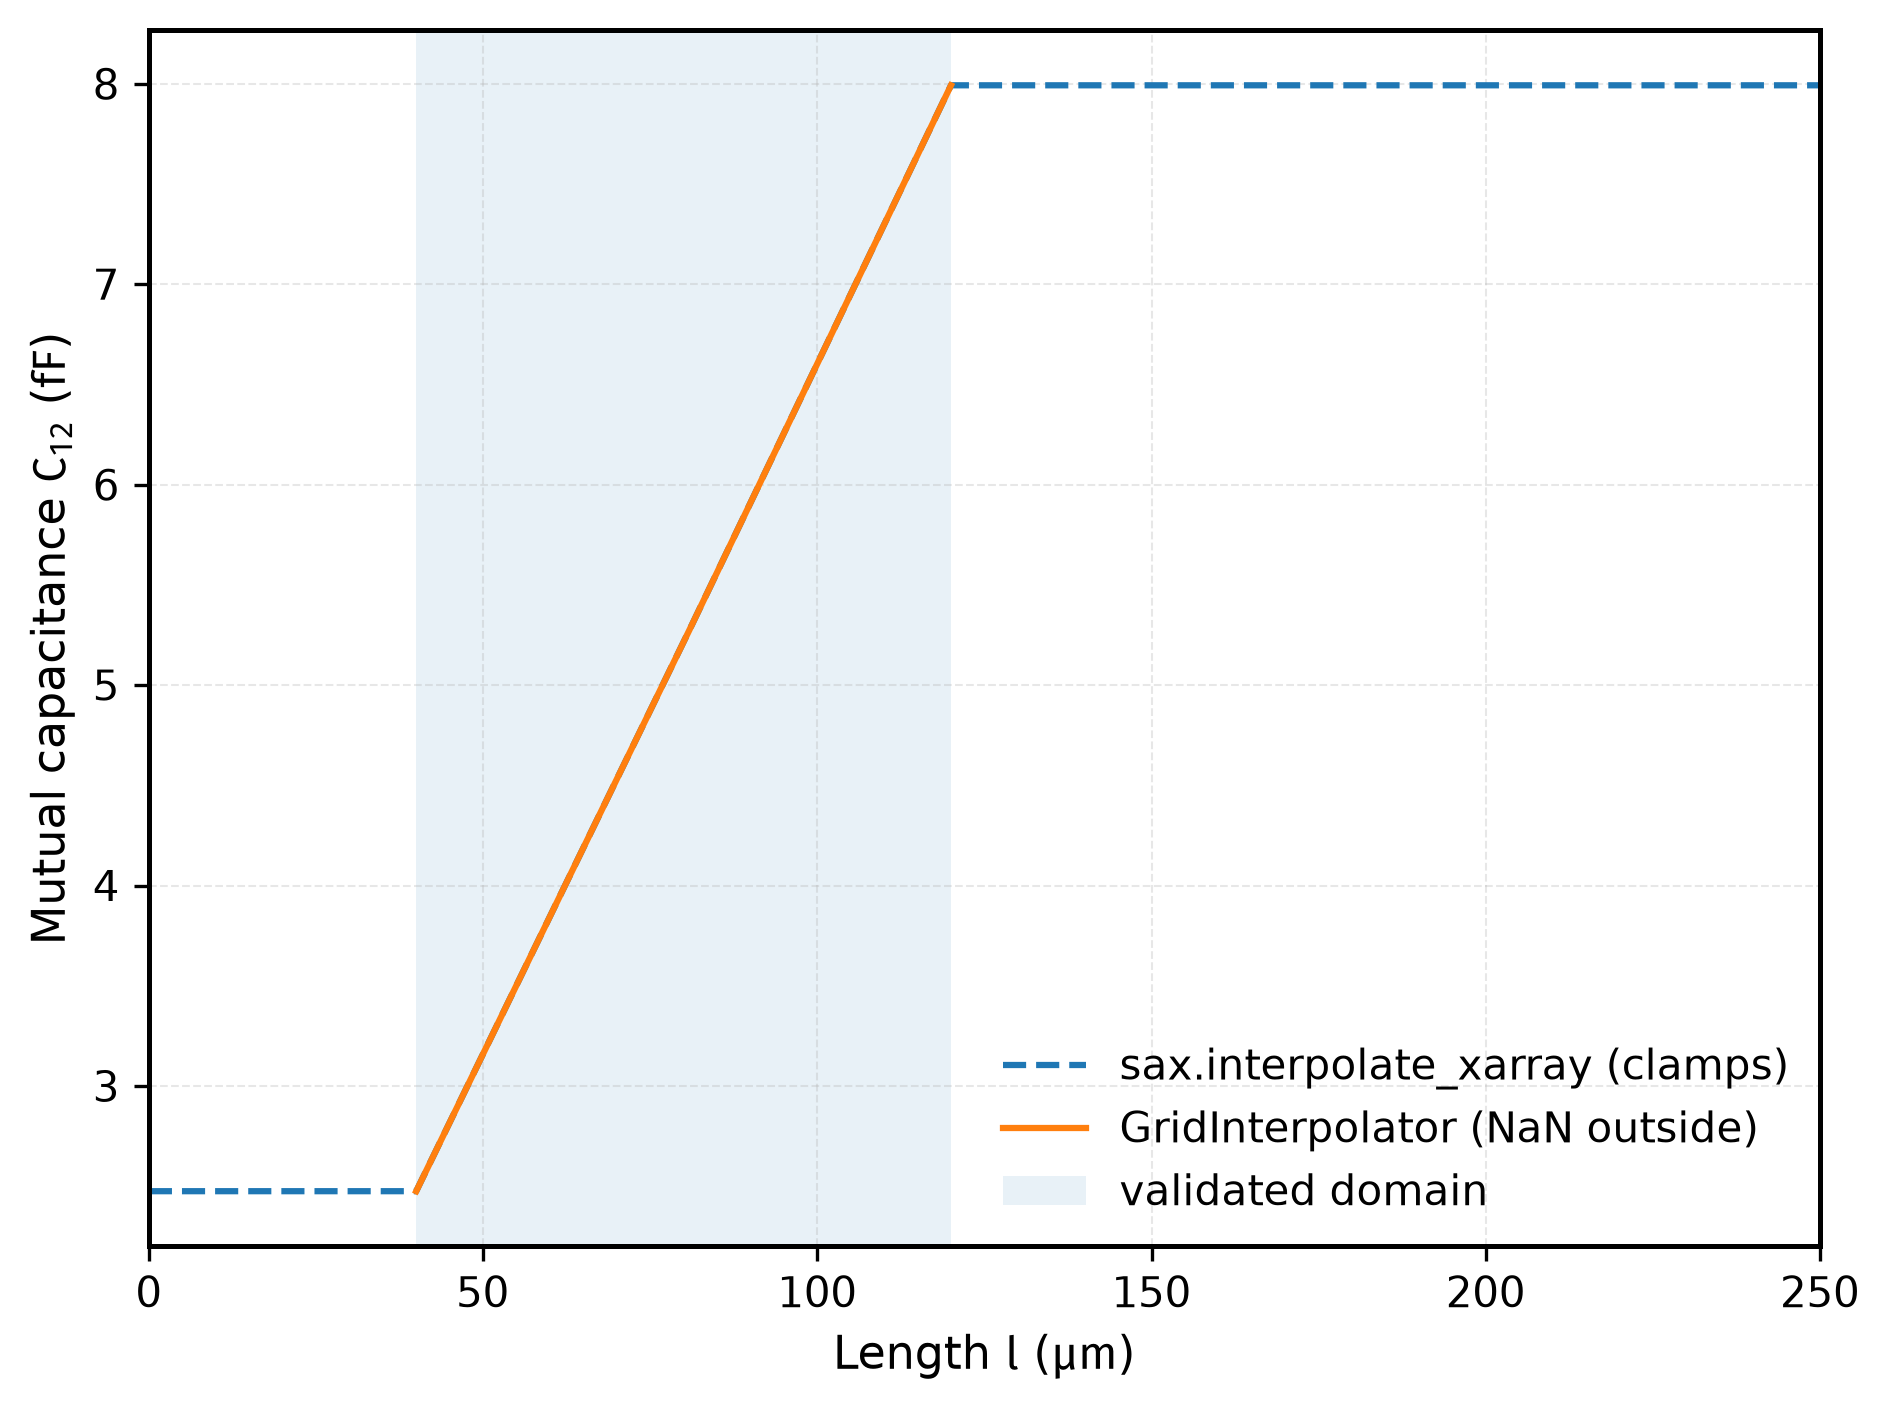

In [10]:
lengths = jnp.linspace(0.0, 250.0, 251)
ours = -c_maxwell(length=lengths, width=10.0, gap=5.0)[:, 0, 1]

xarr = xr.DataArray(
    grid.values.reshape(*grid.values.shape[:3], 4),
    coords={
        **dict(zip(grid.axis_names, grid.coords, strict=True)),
        "targets": np.array(["c11", "c12", "c21", "c22"], dtype=object),
    },
)
theirs = -jax.vmap(
    lambda length: sax.interpolate_xarray(xarr, length=length, width=10.0, gap=5.0)[
        "c12"
    ]
)(lengths)

fig, ax = plt.subplots()
ax.plot(lengths, theirs * 1e15, "--", label="sax.interpolate_xarray (clamps)")
ax.plot(lengths, ours * 1e15, label="GridInterpolator (NaN outside)")
ax.axvspan(*c_maxwell.domain["length"], alpha=0.1, label="validated domain")
ax.set_xlabel(r"Length $l$ ($\text{µm}$)")
ax.set_ylabel(r"Mutual capacitance $C_{12}$ ($\text{fF}$)")
ax.legend()
plt.show()

## Replace an explicit capacitance in a SAX model

{func}`~qpdk.models.capacitor.plate_capacitor` computes its capacitance from a
closed-form expression. The same circuit can take the mutual capacitance from
the dataset instead. The analytical formula and FEM model include different
geometry and ground assumptions, so their disagreement is visible here. The
lookup uses only the mutual branch; a complete circuit can also include the
extracted pad-to-ground capacitances. `capacitance_model` supplies that complete lumped
N-port network for any number of terminals; `s_parameters_model` directly interpolates
stored N-port scattering data.

2026-10-10 06:23:58.044 | INFO     | __main__:<module>:18 - Complete two-terminal network at 5 GHz: {('o1', 'o1'): Array(0.99896342-0.04348968j, dtype=complex128), ('o1', 'o2'): Array(0.00058485+0.01343128j, dtype=complex128), ('o2', 'o1'): Array(0.00058485+0.01343128j, dtype=complex128), ('o2', 'o2'): Array(0.99896263-0.04350777j, dtype=complex128)}


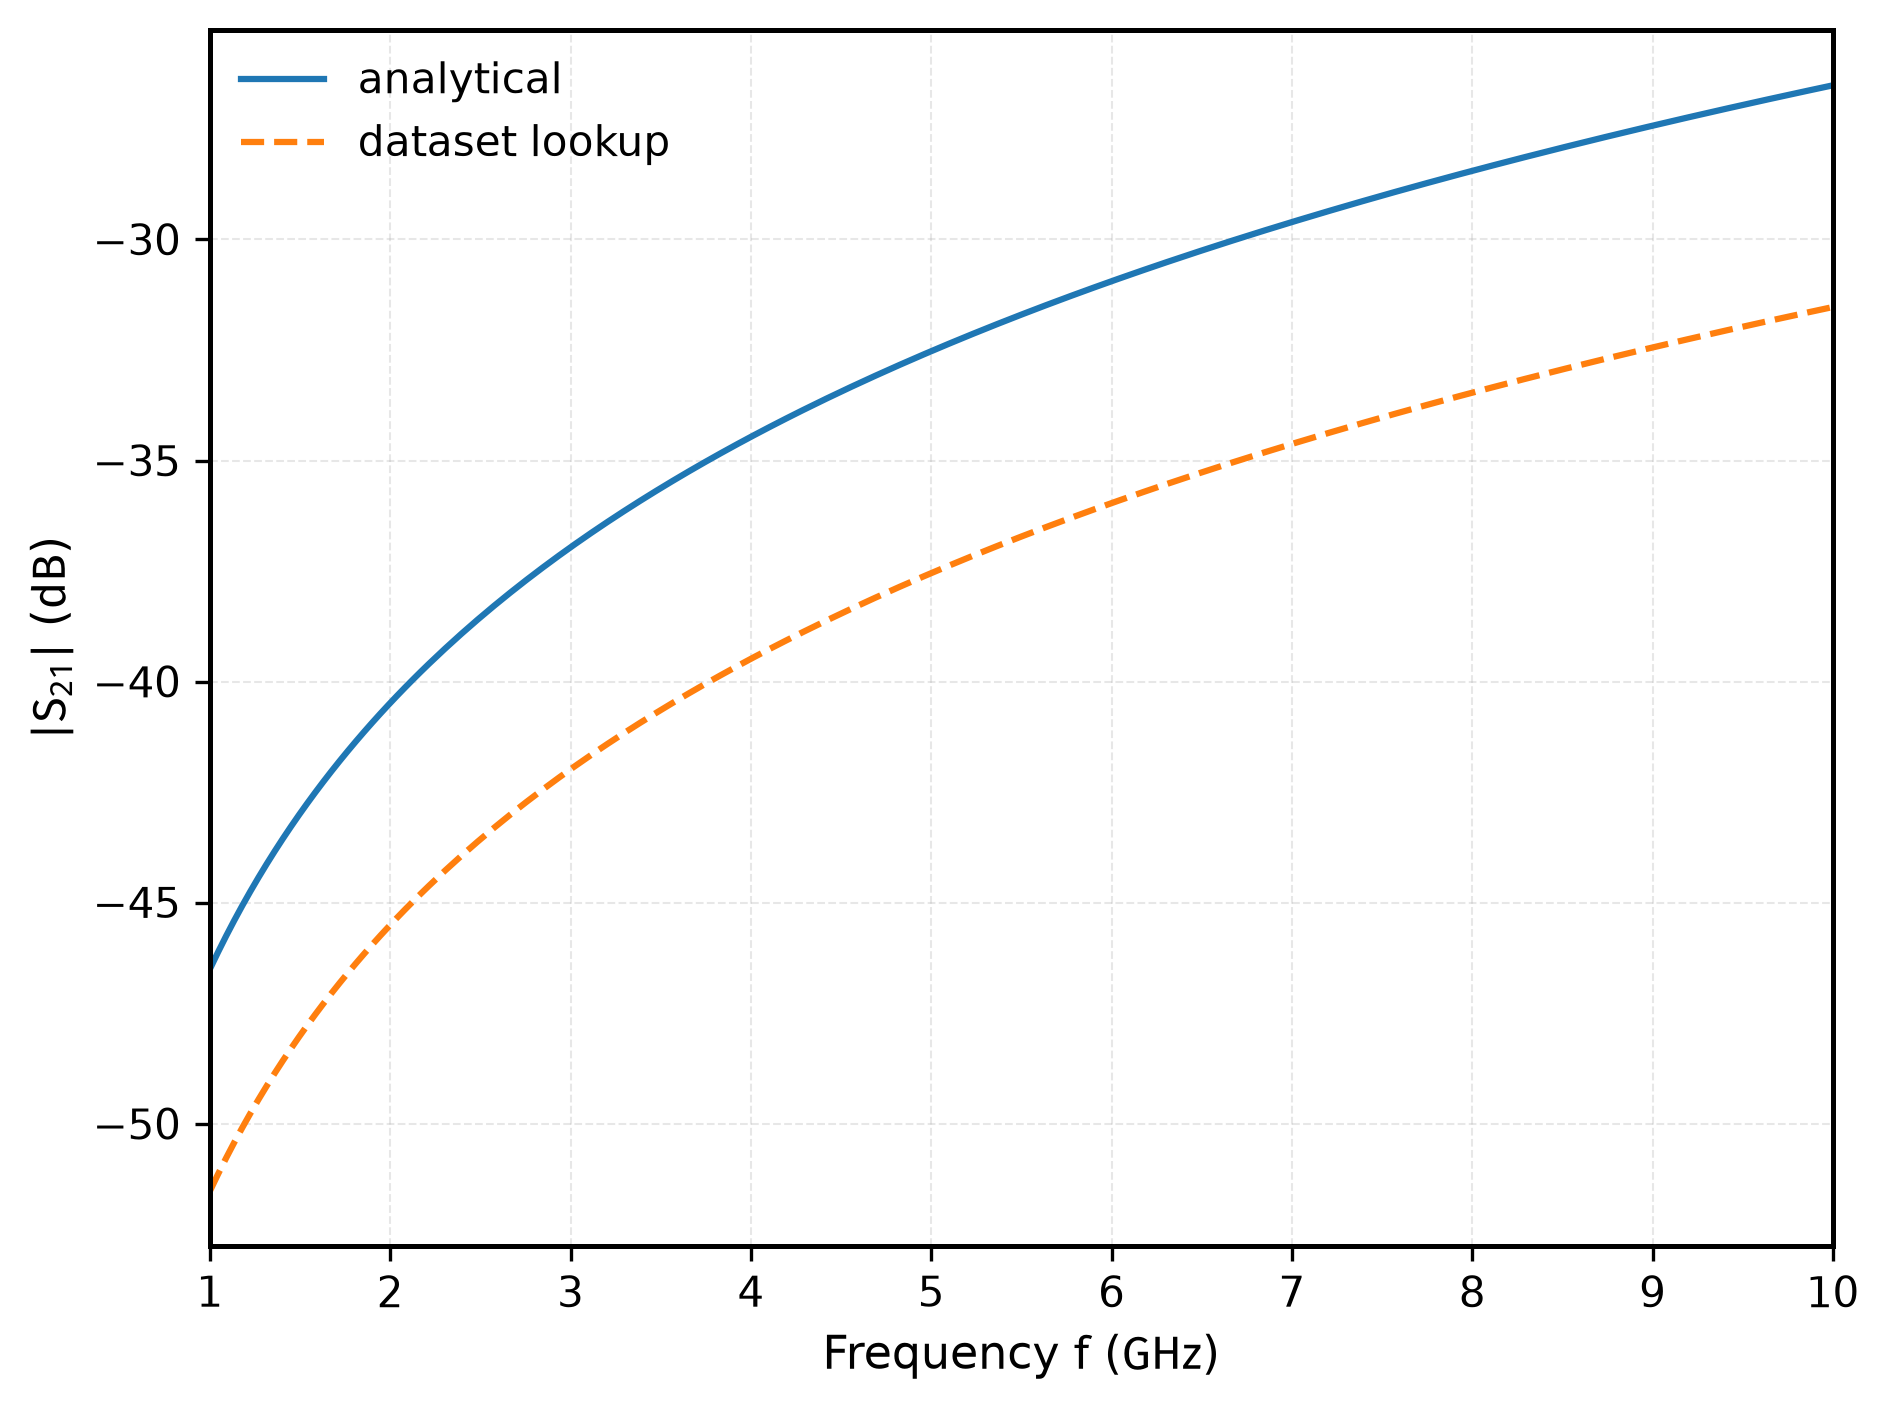

In [11]:
def plate_capacitor_lookup(
    *,
    f=DEFAULT_FREQUENCY,
    length: float = 80.0,
    width: float = 5.0,
    gap: float = 7.0,
    cross_section="cpw",
) -> sax.SDict:
    """Plate capacitor with the mutual capacitance looked up from the dataset."""
    f = jnp.asarray(f)
    c_mutual = maxwell_to_mutual(c_maxwell(length=length, width=width, gap=gap))[0, 1]
    return capacitor(
        f=f, capacitance=c_mutual, z0=cpw_z0_from_cross_section(cross_section, f)
    )


complete_plate = capacitance_model(dataset, cross_section="cpw")
logger.info(
    f"Complete two-terminal network at 5 GHz: "
    f"{complete_plate(f=5e9, length=80.0, width=10.0, gap=7.0)}"
)

f = jnp.linspace(1e9, 10e9, 201)
s_lookup = jax.jit(
    lambda gap: plate_capacitor_lookup(f=f, length=80.0, width=10.0, gap=gap)
)(7.0)
s_analytical = plate_capacitor(f=f, length=80.0, width=10.0, gap=7.0)

fig, ax = plt.subplots()
ax.plot(f / 1e9, 20 * jnp.log10(jnp.abs(s_analytical["o1", "o2"])), label="analytical")
ax.plot(
    f / 1e9, 20 * jnp.log10(jnp.abs(s_lookup["o1", "o2"])), "--", label="dataset lookup"
)
ax.set_xlabel(r"Frequency $f$ ($\text{GHz}$)")
ax.set_ylabel(r"$|S_{21}|$ ($\text{dB}$)")
ax.legend()
plt.show()

The lookup is differentiable, so the gap can be tuned by gradient descent
towards a target transmission.

In [12]:
d_s21_d_gap = jax.jit(
    jax.grad(
        lambda gap: jnp.abs(
            plate_capacitor_lookup(f=5e9, length=80.0, width=10.0, gap=gap)["o1", "o2"]
        )
    )
)
logger.info(f"d|S21|/d gap at 5 GHz, gap = 7 µm: {float(d_s21_d_gap(7.0)):.3e} 1/µm")

## Compile and query time

Compile time and steady-state query time are measured separately, for a single
point and for a batch of 10 000 points.

In [13]:
def benchmark(fn, *args, repeats: int = 50) -> tuple[float, float]:
    """Return (compile time, steady-state time per call) in ms."""
    jitted = jax.jit(fn)
    t0 = time.perf_counter()
    jax.block_until_ready(jitted(*args))
    compile_ms = (time.perf_counter() - t0) * 1e3
    t0 = time.perf_counter()
    for _ in range(repeats):
        jax.block_until_ready(jitted(*args))
    return compile_ms, (time.perf_counter() - t0) / repeats * 1e3


rng = np.random.default_rng(0)
batch = {
    name: jnp.asarray(rng.uniform(lo, hi, 10_000))
    for name, (lo, hi) in c_maxwell.domain.items()
}
single = {name: x[0] for name, x in batch.items()}

rows = []
for label, point in [("1 point", single), ("10 000 points", batch)]:
    for method, fn in [
        ("GridInterpolator", lambda p: c_maxwell(**p)[..., 0, 1]),
        ("sax.interpolate_xarray", lambda p: sax.interpolate_xarray(xarr, **p)["c12"]),
    ]:
        compile_ms, query_ms = benchmark(fn, point)
        rows.append({
            "method": method,
            "query": label,
            "compile_ms": compile_ms,
            "query_ms": query_ms,
        })
pl.DataFrame(rows)

method,query,compile_ms,query_ms
str,str,f64,f64
"""GridInterpolator""","""1 point""",66.489166,0.022261
"""sax.interpolate_xarray""","""1 point""",51.348667,0.017757
"""GridInterpolator""","""10 000 points""",69.841166,0.155626
"""sax.interpolate_xarray""","""10 000 points""",84.361542,0.182277


## Symmetric CPW coupling: a three-dimensional dataset

`qpdk/models/datasets/data/cpw_coupling.py` follows the same workflow, sweeping trace width,
outer CPW slot width and the gap between two identical traces. The inner gap
is fully etched; there is no ground strip between the traces. Both conductors
and the outer ground rails define a two-dimensional transverse Palace mesh,
eliminating end fringing. `Model.Lc` sets the implicit slice depth; stored
capacitances are in F for that depth. The lookup has three geometry axes.

```bash
uv run --script qpdk/models/datasets/data/cpw_coupling.py --dry-run
uv run --script qpdk/models/datasets/data/cpw_coupling.py --sif /path/to/palace.sif
uv run --script qpdk/models/datasets/data/cpw_coupling.py --topology as-drawn --sif /path/to/palace.sif
```

The generator refines every geometry until each raw Maxwell entry changes by
at most 1% between successive meshes and identical traces agree within 1%.
It stores the accepted finer matrix, mesh sizes, refinement level and measured
change. This measures mesh sensitivity; it does not bound domain truncation or
interpolation error. Separate domain, vacuum and held-out checks travel in the
bundled dataset's provenance. Solver matrices remain raw.
The smaller development grid trades lookup resolution for faster regeneration;
check its measured interpolation error before extending a design sweep.

The following cells read the bundled Palace results and run no simulator.
The same interpolator handles all three axes; fixing an axis only chooses a
view of that three-dimensional lookup.

In [14]:
cpw_dataset = Dataset("cpw_coupling_palace")
cpw_grid = cpw_dataset.grid("maxwell_capacitance")
cpw_lookup = GridInterpolator(cpw_grid)
slice_length = cpw_dataset.metadata.provenance["settings"]["slice_length_um"] * 1e-6
logger.info(f"CPW grid: {cpw_grid.values.shape}; domain: {cpw_lookup.domain}")

2026-10-10 06:23:59.062 | INFO     | __main__:<module>:5 - CPW grid: (15, 13, 35, 2, 2); domain: {'width': (2.0, 30.0), 'cpw_gap': (1.0, 20.0), 'gap': (1.0, 250.0)}


### Find simulations to refine

Filter and project before collecting. The mesh change is the measured refinement
check; the FEM norm ranks results to inspect and is not a capacitance error bound.
Trace mismatch and comparison with conformal mapping provide independent flags.
A flagged result needs investigation, even when its linear solve converged.


In [15]:
diagnostic_names = (
    "fem_error_indicator_norm",
    "solver_relative_residual",
    "solver_iterations",
    "analytical_mutual_relative_difference",
    "mesh_relative_change",
    "mesh_refinement_level",
    "mesh_near_size",
    "mesh_far_size",
)
diagnostics = (
    cpw_dataset
    .scan()
    .filter(pl.col("quantity").is_in(diagnostic_names))
    .select("width", "cpw_gap", "gap", "quantity", "value")
    .group_by("width", "cpw_gap", "gap")
    .agg(
        pl.col("value").filter(pl.col("quantity") == name).first().alias(name)
        for name in diagnostic_names
    )
)
symmetry = (
    cpw_dataset
    .scan()
    .filter(pl.col("quantity") == "maxwell_capacitance", pl.col("row") == pl.col("col"))
    .select("width", "cpw_gap", "gap", "value")
    .group_by("width", "cpw_gap", "gap")
    .agg(
        trace_mismatch=(pl.col("value").max() - pl.col("value").min())
        / pl.col("value").mean()
    )
)
indicator = pl.col("fem_error_indicator_norm")
(
    diagnostics
    .join(symmetry, on=["width", "cpw_gap", "gap"])
    .with_columns(
        flag_for_refinement=(
            indicator
            > indicator.quantile(0.75)
            + 1.5 * (indicator.quantile(0.75) - indicator.quantile(0.25))
        )
        | (pl.col("mesh_relative_change") > 0.01)
        | (pl.col("trace_mismatch") > 0.01)
        | (pl.col("analytical_mutual_relative_difference").abs() > 0.03)
    )
    .sort(
        pl.col("flag_for_refinement"),
        pl.col("analytical_mutual_relative_difference").abs(),
        pl.col("fem_error_indicator_norm"),
        descending=True,
    )
    .head(10)
    .collect()
)

width,cpw_gap,gap,fem_error_indicator_norm,solver_relative_residual,solver_iterations,analytical_mutual_relative_difference,mesh_relative_change,mesh_refinement_level,mesh_near_size,mesh_far_size,trace_mismatch,flag_for_refinement
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool
12.0,12.0,1.25,0.166969,5.2943e-10,15.0,0.01644,0.009366,1.0,0.0000001,0.00002,0.000372,true
2.0,1.0,225.0,0.170495,9.1787e-10,14.0,0.015964,0.007504,1.0,0.0000001,0.00002,0.000419,true
7.0,1.0,1.25,0.195411,3.5514e-10,15.0,0.013565,0.008251,1.0,0.0000001,0.00002,0.009727,true
7.0,1.0,2.0,0.190366,8.7203e-10,16.0,0.013405,0.009292,1.0,0.0000001,0.00002,0.008965,true
6.0,1.0,1.0,0.166724,9.8633e-10,15.0,0.012729,0.00215,1.0,0.0000001,0.00002,0.000298,true
14.0,8.0,1.0,0.169639,8.8213e-10,16.0,0.012169,0.005303,1.0,0.0000001,0.00002,0.001142,true
8.0,1.0,1.0,0.168318,2.9870e-10,15.0,0.011864,0.002508,1.0,0.0000001,0.00002,0.000095,true
2.0,1.0,175.0,0.169946,8.4679e-10,14.0,0.011443,0.008207,1.0,0.0000001,0.00002,0.000635,true
7.0,1.0,1.0,0.171637,2.5094e-10,15.0,0.01123,0.002252,1.0,0.0000001,0.00002,0.000136,true


### A two-dimensional heatmap

At a fixed outer slot width, vary trace width and inter-trace gap together.
The black dots mark solved geometries; colours between them are interpolation.
The logarithmic colour scale resolves weak coupling at large separations.

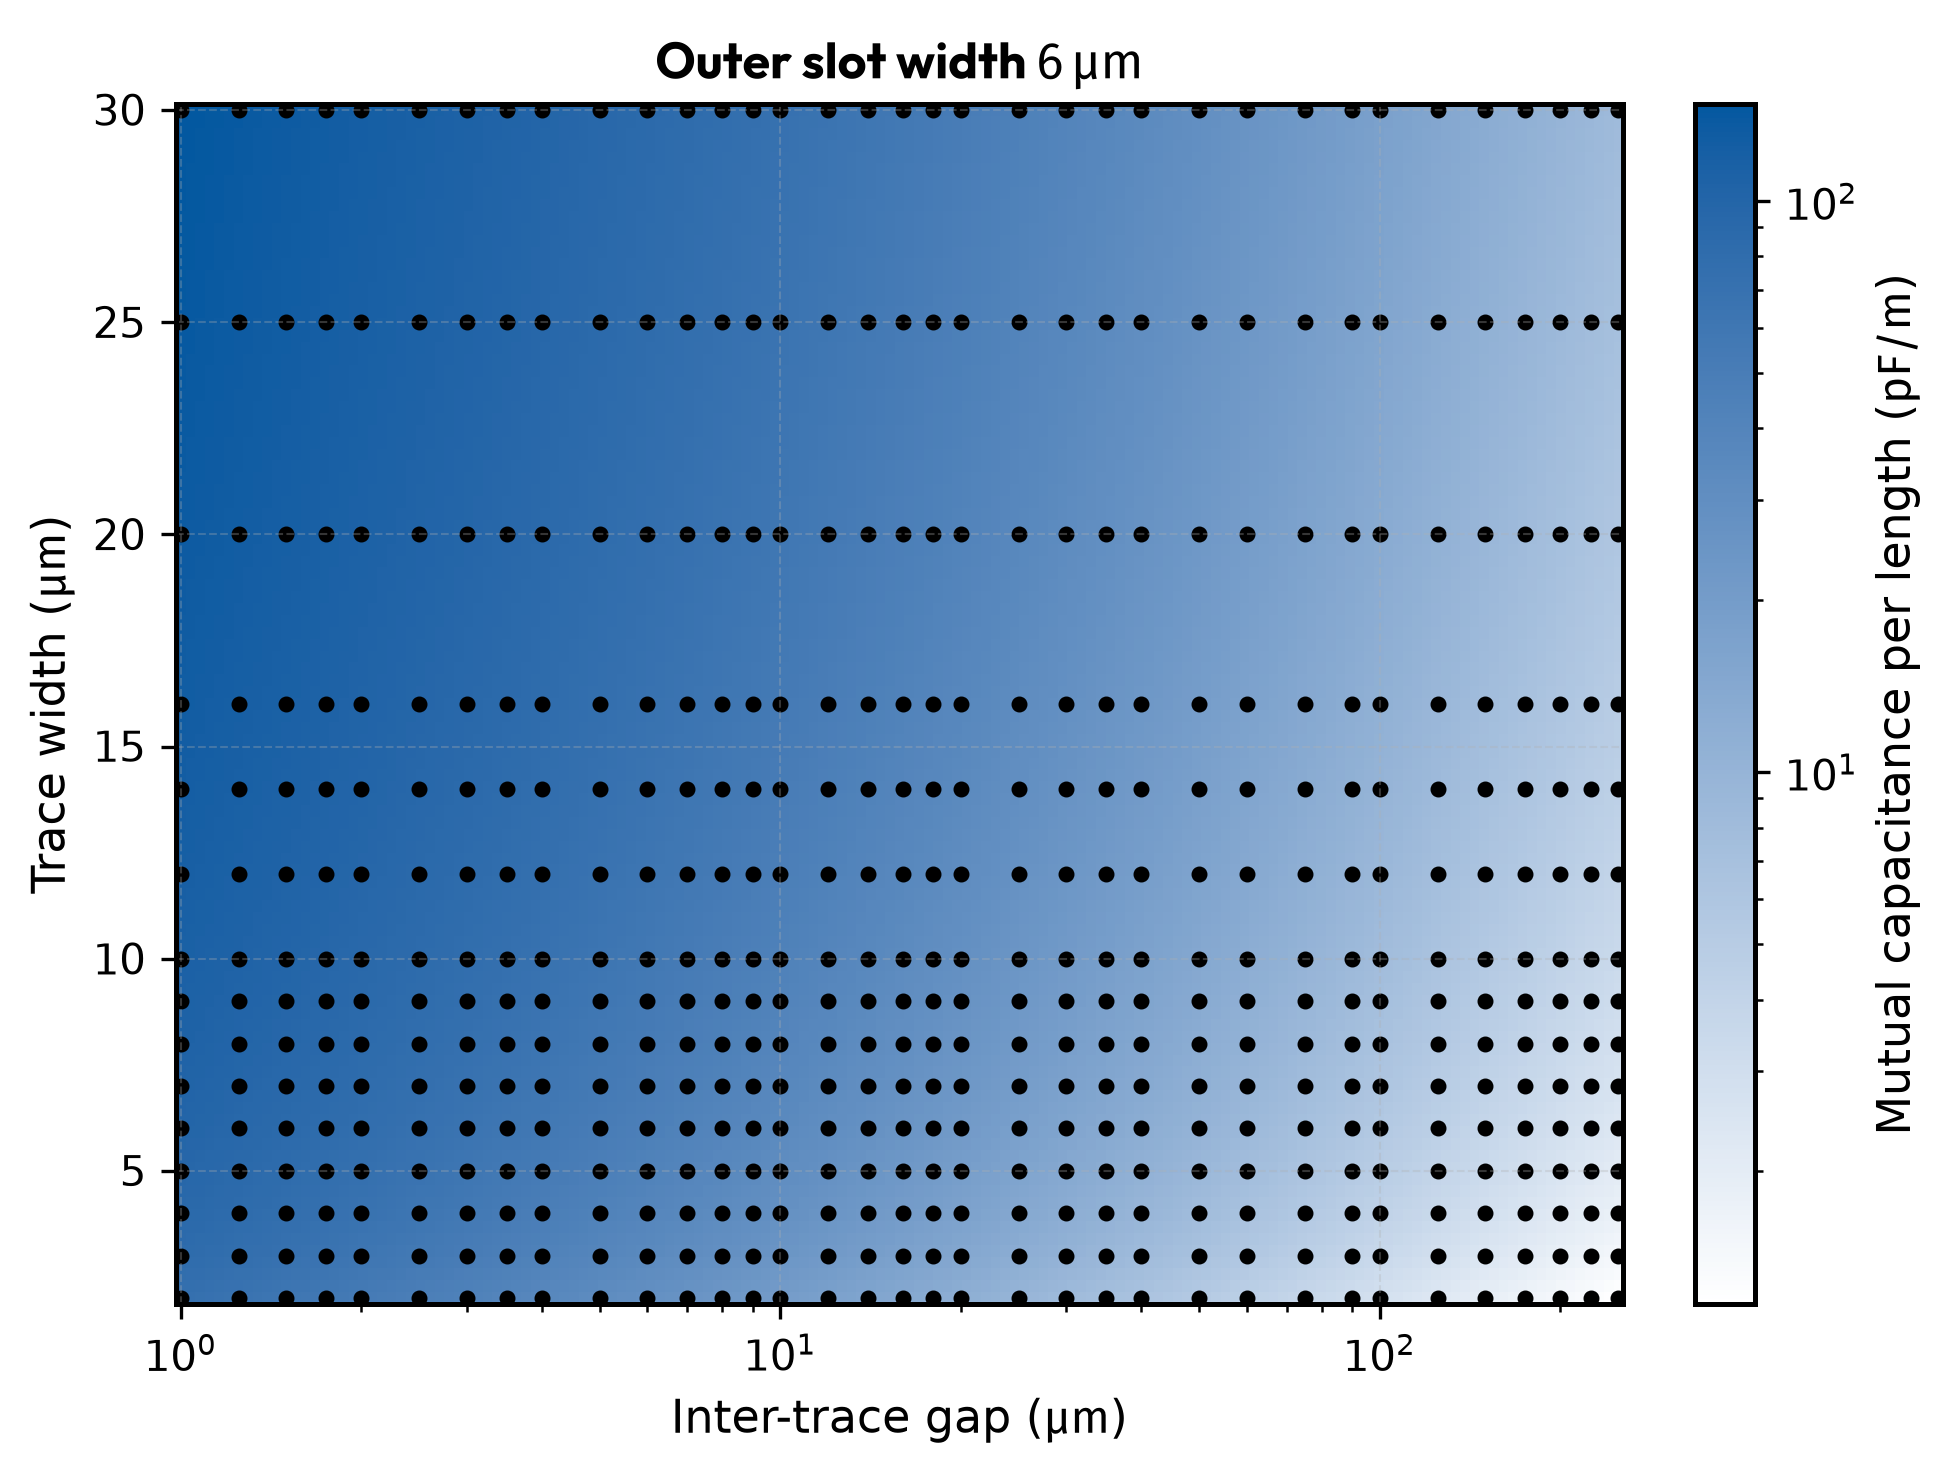

In [16]:
width_axis = jnp.linspace(*cpw_lookup.domain["width"], 101)
gap_axis = jnp.geomspace(*cpw_lookup.domain["gap"], 151)
W, G = jnp.meshgrid(width_axis, gap_axis, indexing="ij")
mutual_per_length = -cpw_lookup(width=W, cpw_gap=6.0, gap=G)[..., 0, 1] / slice_length
fig, ax = plt.subplots(constrained_layout=True)
image = ax.pcolormesh(
    gap_axis,
    width_axis,
    mutual_per_length * 1e12,
    cmap=QPDK,
    norm=LogNorm(),
    shading="auto",
    rasterized=True,
)
solved_width, solved_gap = jnp.meshgrid(
    cpw_grid.coords[0], cpw_grid.coords[2], indexing="ij"
)
ax.scatter(solved_gap, solved_width, s=8, color="black")
ax.set_xlabel(r"Inter-trace gap ($\text{µm}$)")
ax.set_xscale("log")
ax.set_ylabel(r"Trace width ($\text{µm}$)")
ax.set_title(r"Outer slot width $6\,\text{µm}$")
fig.colorbar(image, ax=ax, label=r"Mutual capacitance per length ($\text{pF/m}$)")
plt.show()

### Slices through the three-dimensional lookup

These three heatmaps vary all three parameters: the outer slot width changes
between panels, while each panel scans trace width and inter-trace gap. A
shared colour scale makes the effect of the third axis visible. The middle
panel's slot width lies between stored grid points.

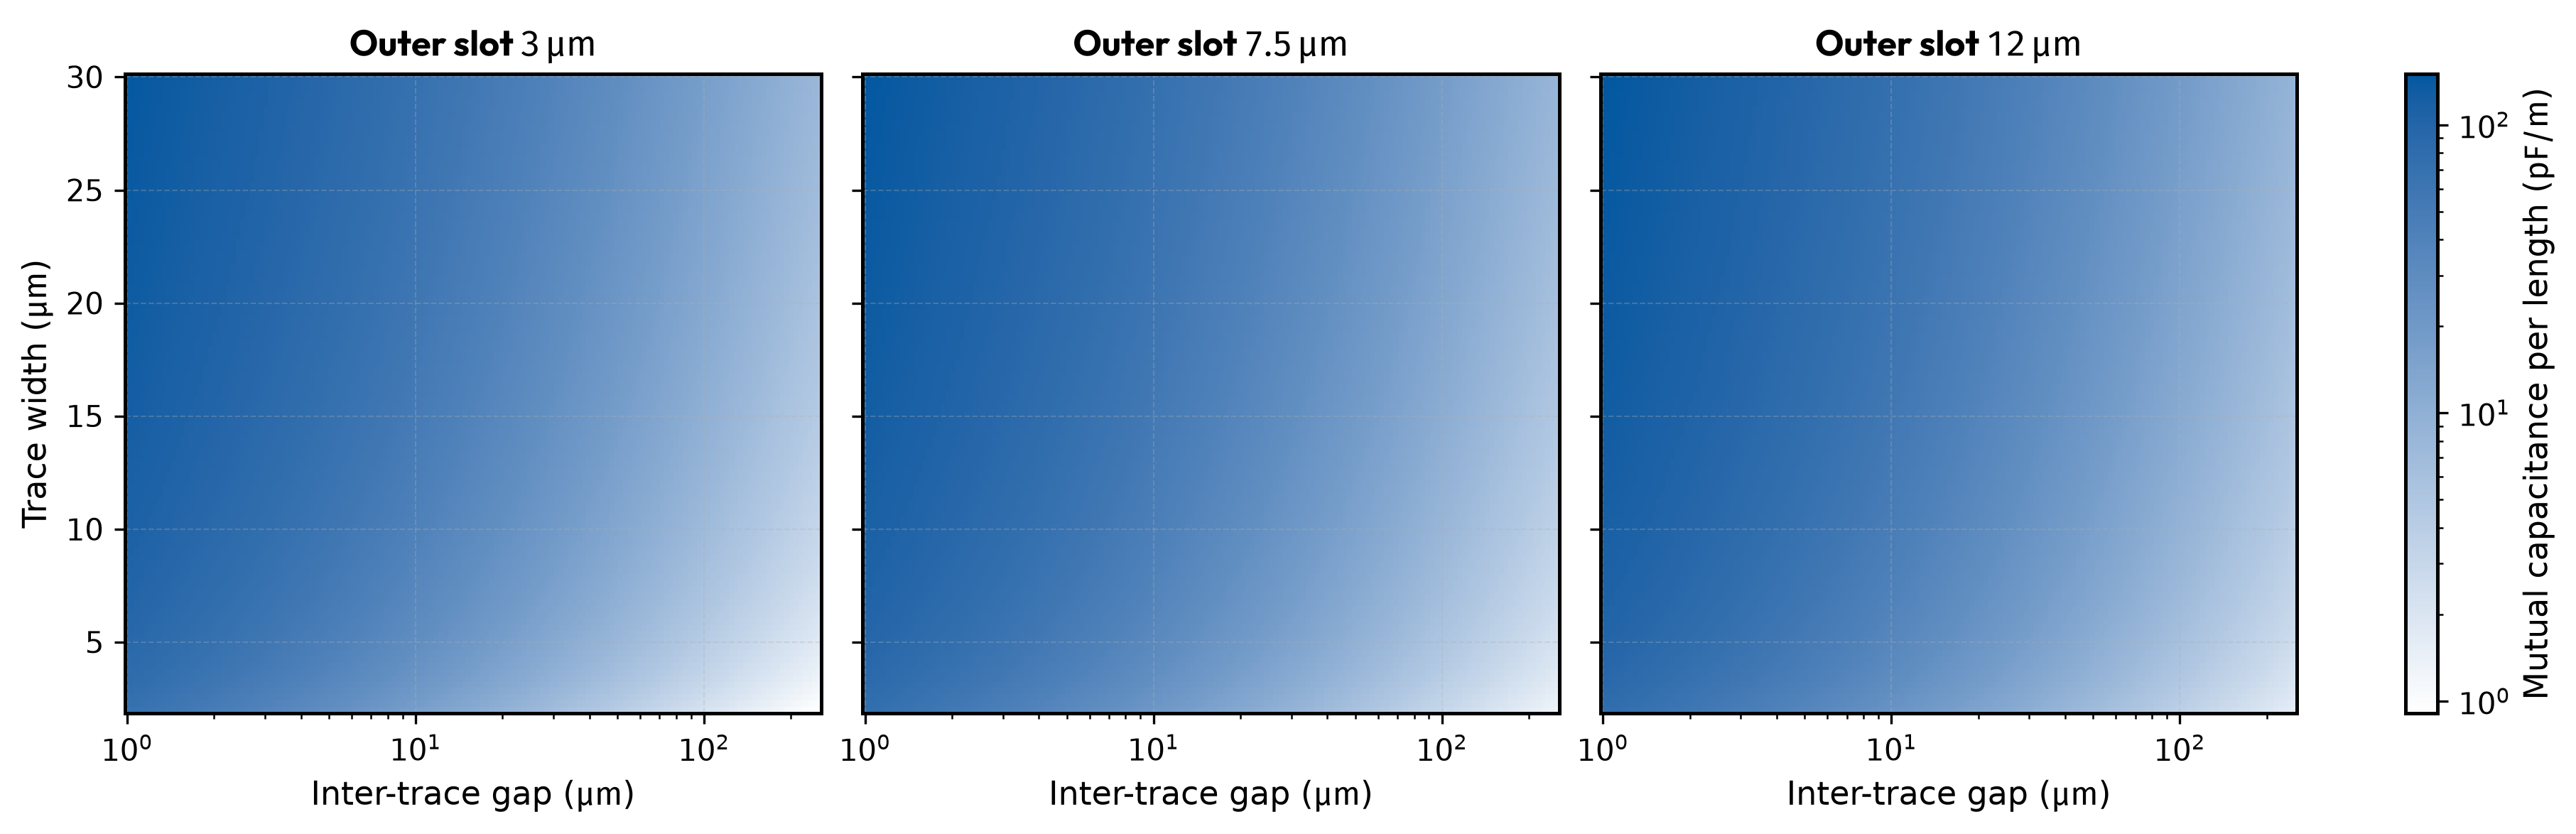

In [17]:
outer_slots = jnp.array([3.0, 7.5, 12.0])
volume_slices = (
    -cpw_lookup(
        width=W[None, ...], cpw_gap=outer_slots[:, None, None], gap=G[None, ...]
    )[..., 0, 1]
    / slice_length
    * 1e12
)
fig, axes = plt.subplots(
    1, 3, figsize=(12, 3.8), sharex=True, sharey=True, constrained_layout=True
)
heatmap_norm = LogNorm(vmin=float(volume_slices.min()), vmax=float(volume_slices.max()))
for i, ax in enumerate(axes):
    image = ax.pcolormesh(
        gap_axis,
        width_axis,
        volume_slices[i],
        cmap=QPDK,
        norm=heatmap_norm,
        shading="auto",
        rasterized=True,
    )
    ax.set_title(rf"Outer slot ${float(outer_slots[i]):g}\,\text{{µm}}$")
    ax.set_xlabel(r"Inter-trace gap ($\text{µm}$)")
    ax.set_xscale("log")
axes[0].set_ylabel(r"Trace width ($\text{µm}$)")
fig.colorbar(
    image, ax=list(axes), label=r"Mutual capacitance per length ($\text{pF/m}$)"
)
plt.show()

### Compare with conformal mapping

The analytical edge-coupled CPW expression assumes the same conductor sheets
and dielectric half-spaces. Compare mutual capacitance per length directly,
before turning either result into a circuit model.

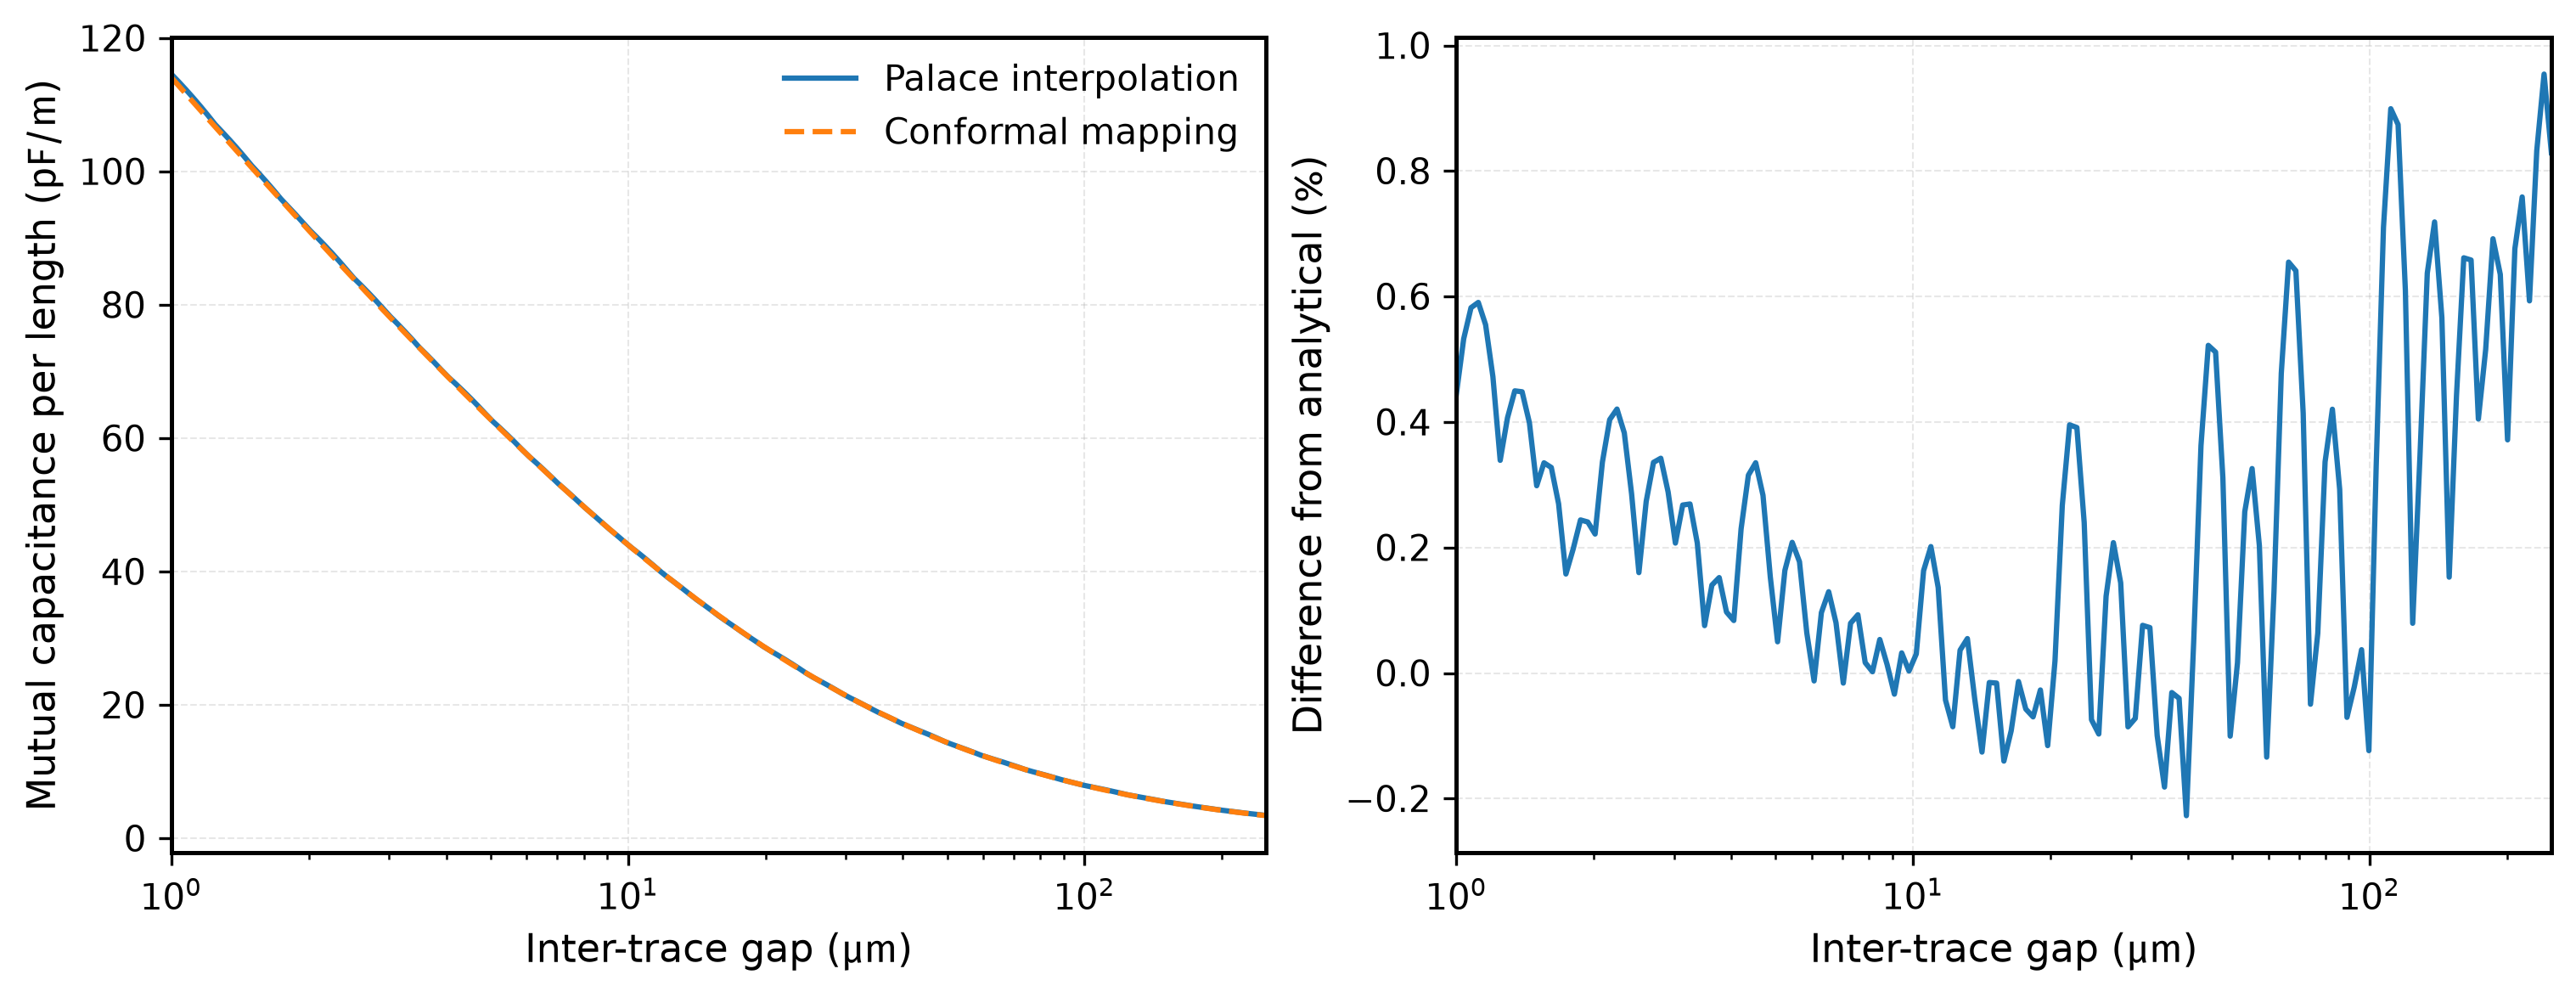

In [18]:
analytical = cpw_cpw_coupling_capacitance_per_length_analytical(
    gap=gap_axis,
    width=10.0,
    cpw_gap=6.0,
    ep_r=cpw_dataset.metadata.provenance["settings"]["permittivity"],
)
fem = -cpw_lookup(width=10.0, cpw_gap=6.0, gap=gap_axis)[..., 0, 1] / slice_length
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), constrained_layout=True)
axes[0].plot(gap_axis, fem * 1e12, label="Palace interpolation")
axes[0].plot(gap_axis, analytical * 1e12, "--", label="Conformal mapping")
axes[0].set_ylabel(r"Mutual capacitance per length ($\text{pF/m}$)")
axes[0].legend()
axes[1].plot(gap_axis, 100 * (fem / analytical - 1))
axes[1].set_ylabel(r"Difference from analytical ($\text{%}$)")
for ax in axes:
    ax.set_xlabel(r"Inter-trace gap ($\text{µm}$)")
    ax.set_xscale("log")
plt.show()

### Ground left between the CPW slots

![Fully etched inner gap compared with QPDK slots retaining a central ground strip.](figures/cpw-coupling-ground.svg)

`coupler_straight` etches a slot on each side of each trace. When the inter-trace
gap exceeds twice the slot width, a ground strip remains between the slots.
The `as-drawn` experiment keeps this strip at reference ground. It matches the fully etched geometry
while the slots touch or overlap; beyond that point, the ground shields the traces.
The FEM capacitances are solved independently; the analytical expression is used
only for comparison. Both models share ideal sheets and dielectric half-spaces.
The analytical ECCPW formula assumes a fully etched inner gap, so its difference
from the shielded result measures a geometry change as well as numerical error.
Positive strip widths are sampled logarithmically from 0.01 µm. Logarithmic
interpolation follows the rapid shielding onset; narrower strips return NaN.


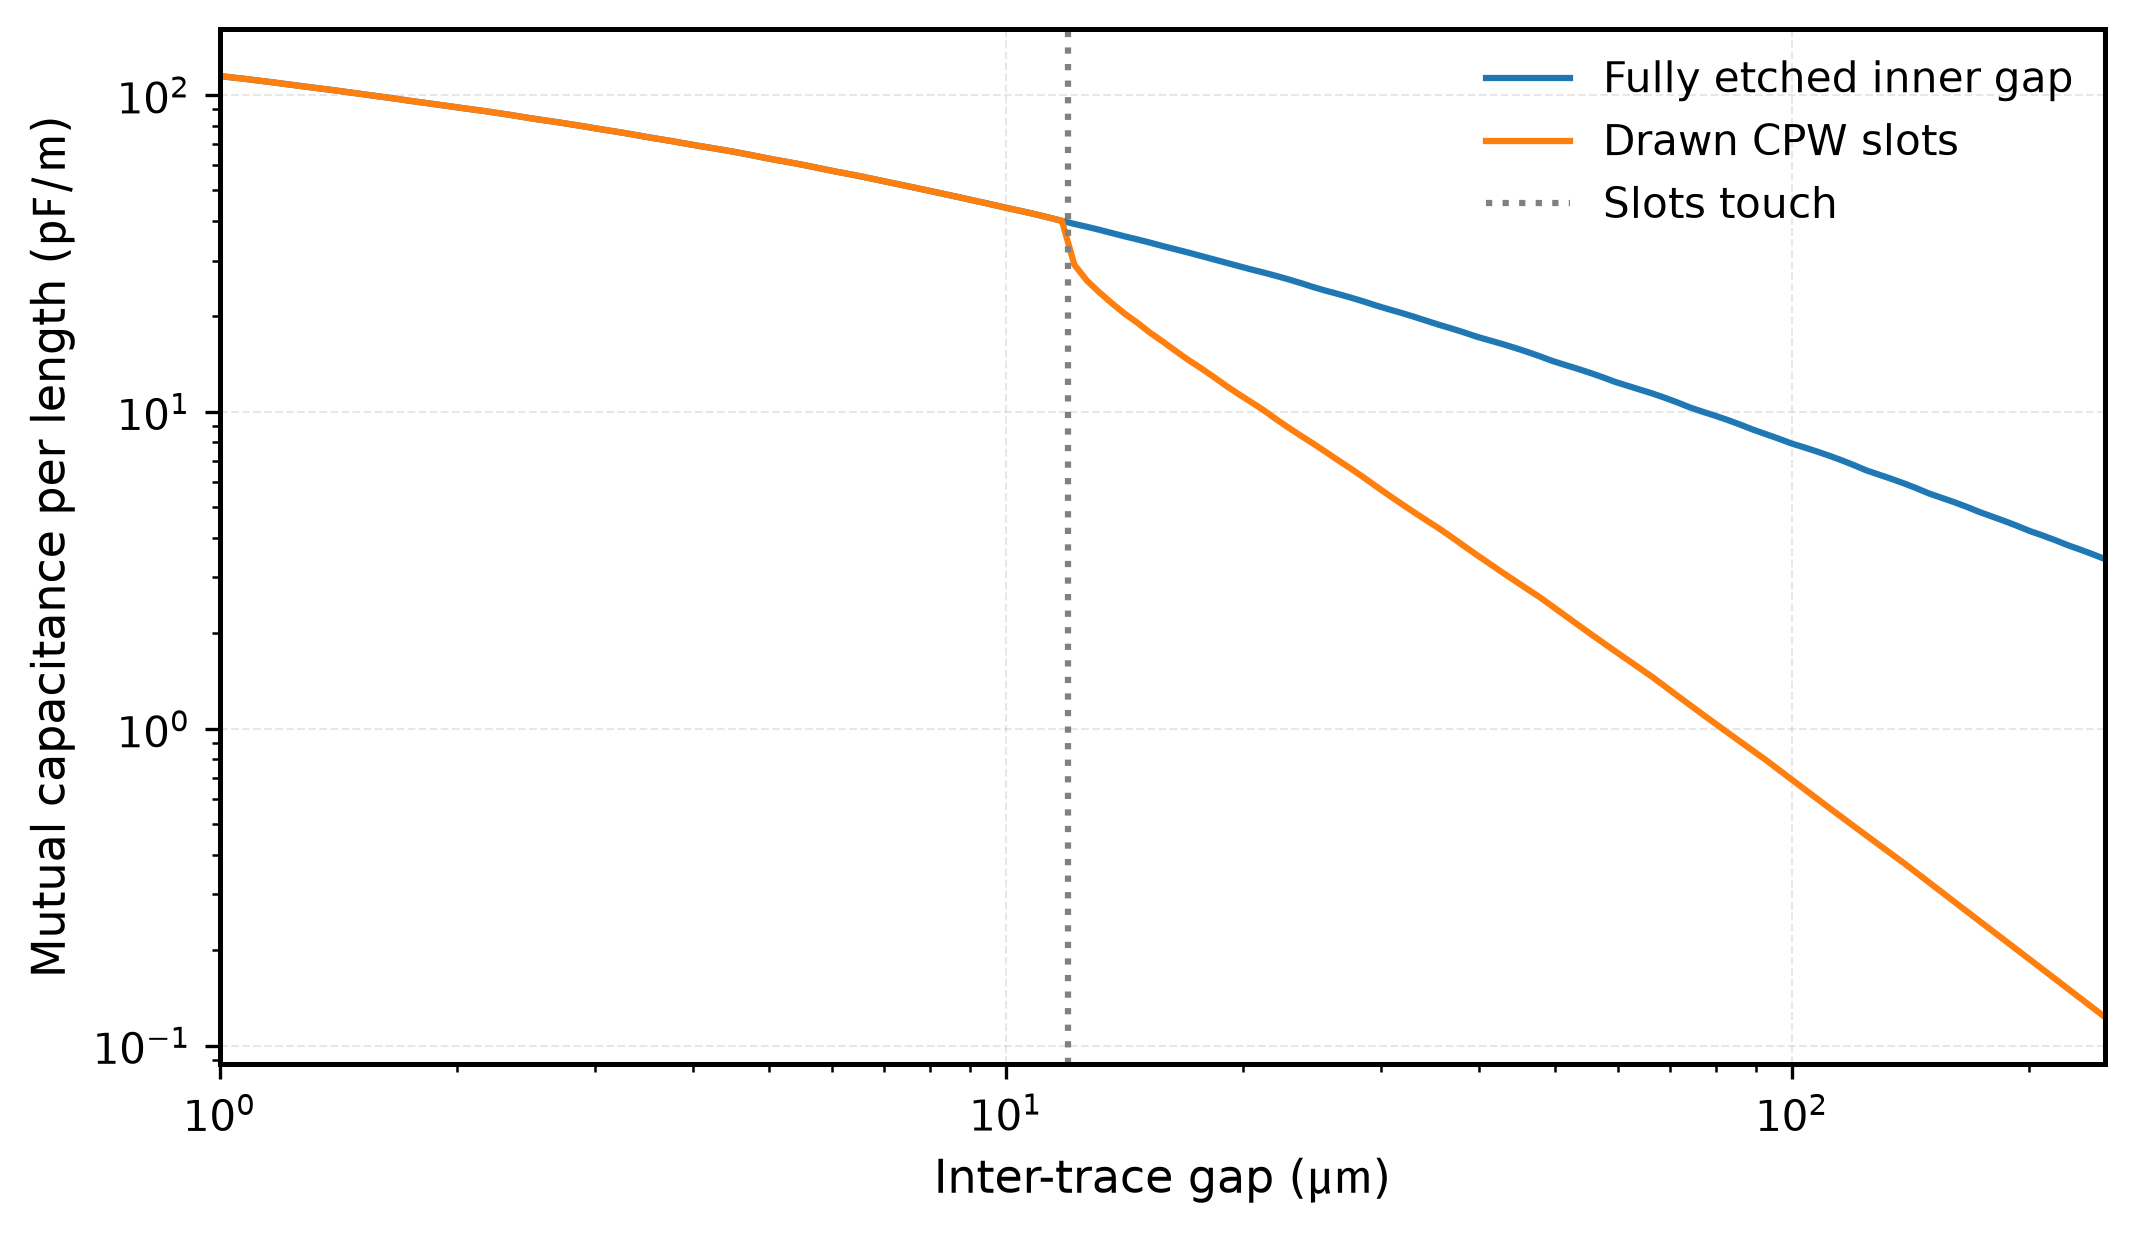

In [19]:
layout_dataset = Dataset("cpw_coupling_ground_strip_palace")
layout_mutual = cpw_cpw_coupling_capacitance(
    f=5e9,
    length=1e6,
    gap=gap_axis,
    cross_section=coplanar_waveguide(width=10.0, gap=6.0),
)
fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
ax.loglog(gap_axis, fem * 1e12, label="Fully etched inner gap")
ax.loglog(gap_axis, layout_mutual * 1e12, label="Drawn CPW slots")
ax.axvline(12.0, color="gray", linestyle=":", label="Slots touch")
ax.set_xlabel(r"Inter-trace gap ($\text{µm}$)")
ax.set_ylabel(r"Mutual capacitance per length ($\text{pF/m}$)")
ax.legend()
plt.show()

Compare both lookups with reference solves refined to a 0.1% successive-mesh
change, larger domains, vacuum scaling and independent held-out geometries.
These finite checks estimate sensitivity; they do not prove a uniform error bound.

In [20]:
quality_rows = []
for label, data in (("Etched gap", cpw_dataset), ("Ground strip", layout_dataset)):
    checks = data.metadata.provenance["validation"]
    quality_rows.append({
        "Geometry": label,
        "Mesh (%)": 100 * checks["maximum_mesh_relative_change"],
        "Reference (%)": 100 * checks["representative_stricter_mesh_max_relative"],
        "Domain (%)": 100 * max(c["domain_relative"] for c in checks["mesh_domain"]),
        "Vacuum (%)": 100
        * max(c.get("vacuum_scaling_relative", 0) for c in checks["mesh_domain"]),
        "Lookup (%)": 100 * checks["held_out_max_relative"],
    })
pl.DataFrame(quality_rows)

Geometry,Mesh (%),Reference (%),Domain (%),Vacuum (%),Lookup (%)
str,f64,f64,f64,f64,f64
"""Etched gap""",0.999793,1.32951,0.840968,0.195495,0.64896
"""Ground strip""",0.99997,1.684355,0.665604,0.00457,1.375807


## A distributed four-port SAX model

{func}`~qpdk.models.couplers.cpw_cpw_coupling_capacitance` uses the layout-matching lookup in
{func}`~qpdk.models.couplers.coupler_straight`. For a distributed section,
{func}`~qpdk.models.couplers.cpw_coupling_model` loads and validates the grid
once, then returns a jittable model of the uniform coupled section. The slice
capacitances determine even- and odd-mode impedances. Geometric inductance
follows the quasi-TEM dielectric half-space relation; kinetic inductance,
finite substrate thickness, dispersion and loss are omitted.

Ports are `o1` lower-left, `o2` upper-left, `o3` upper-right and `o4` lower-right.
Reference planes lie at the section ends. All four ports below use 50 ohm
reference impedances. The remaining ports are matched when reading a single
scattering entry; an open or short circuit must be connected explicitly in SAX.

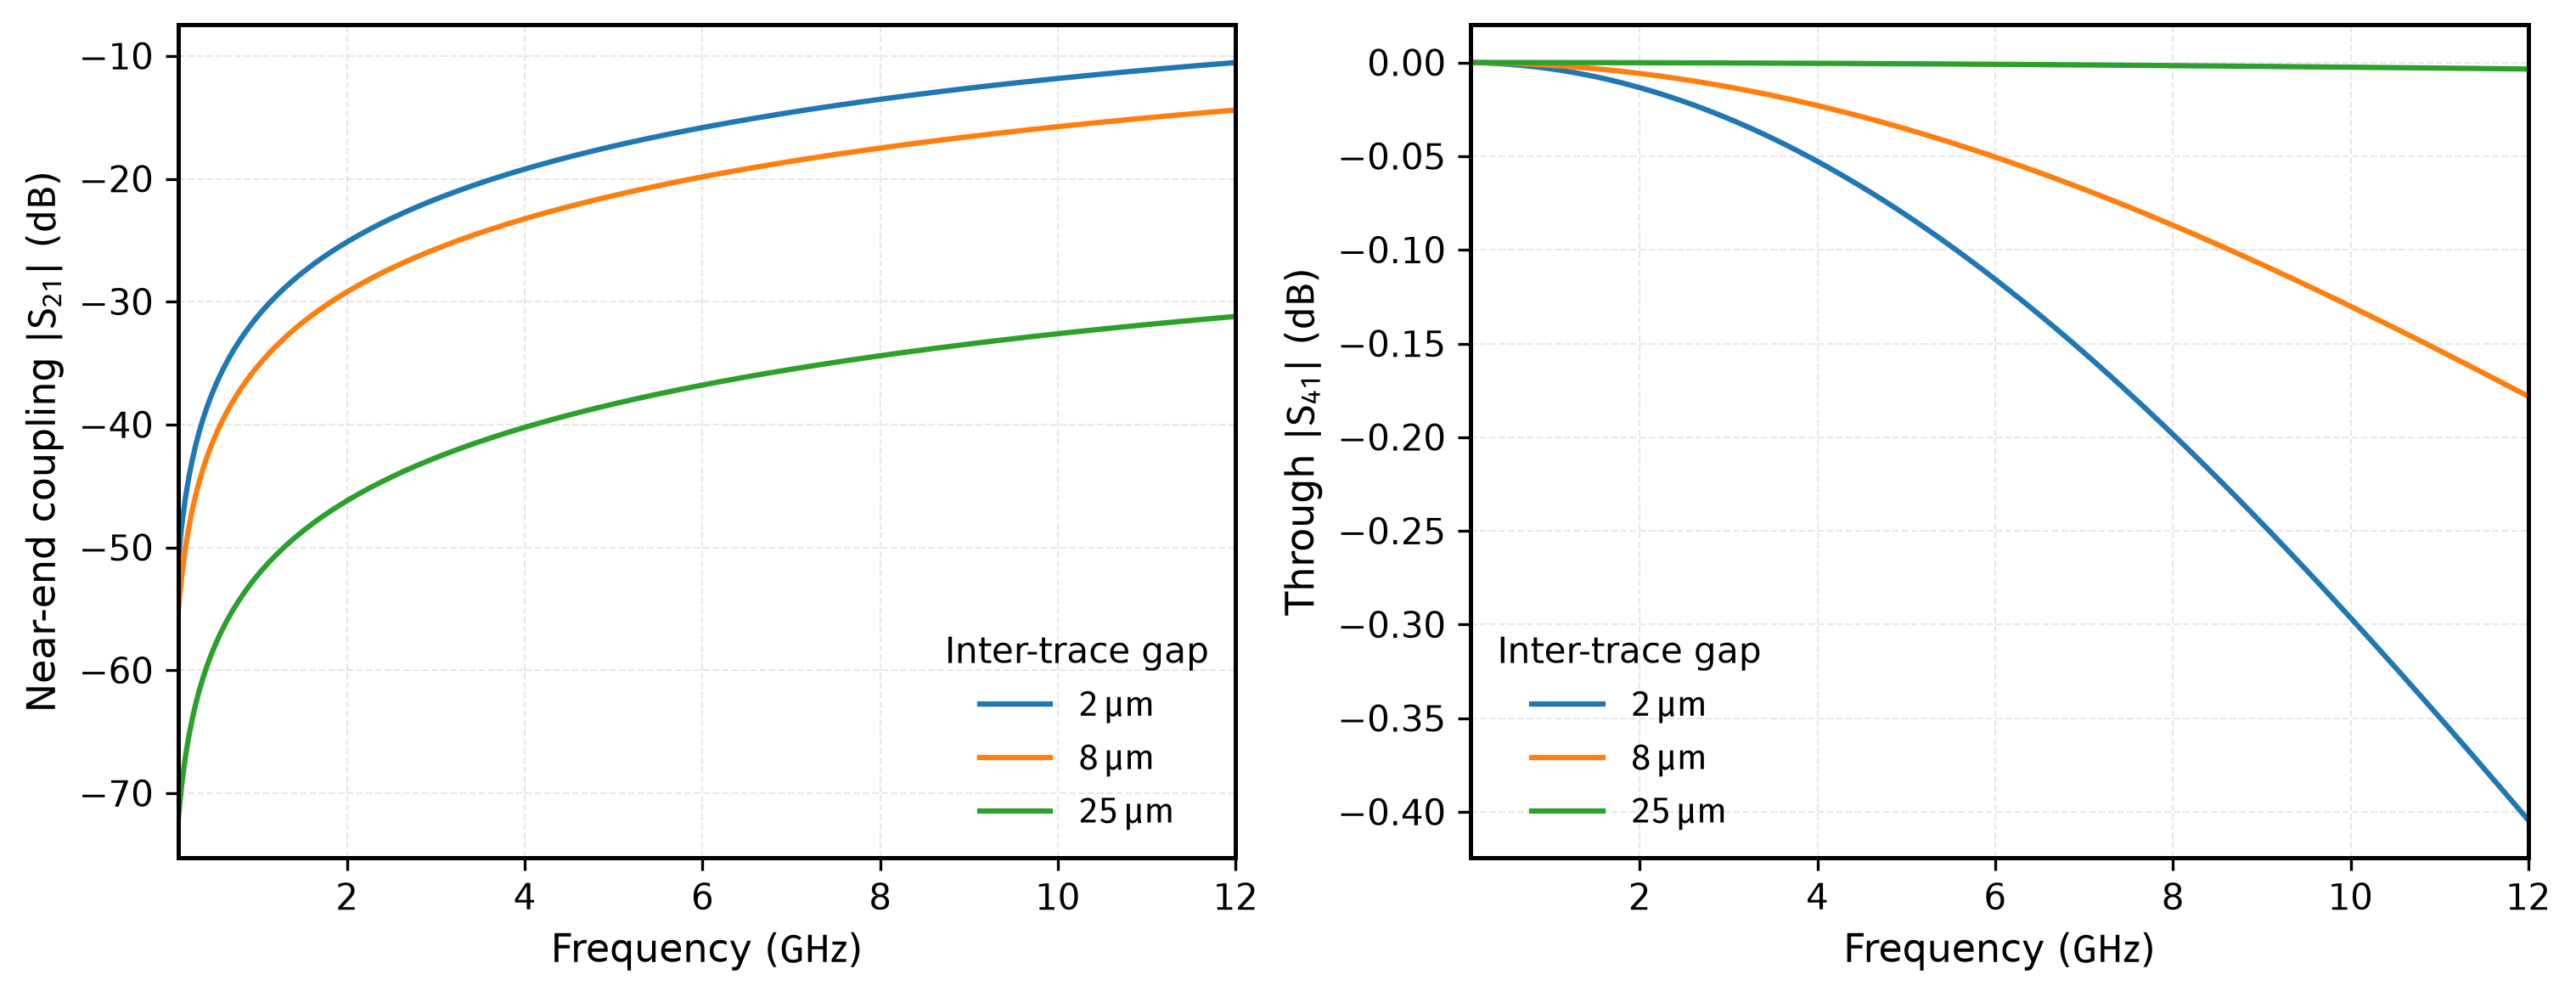

In [21]:
cpw_model = cpw_coupling_model(layout_dataset)
frequencies = jnp.linspace(0.1e9, 12e9, 301)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), constrained_layout=True)
for gap in (2.0, 8.0, 25.0):
    scattering = jax.jit(cpw_model)(
        f=frequencies, length=1000.0, width=10.0, cpw_gap=6.0, gap=gap
    )
    axes[0].plot(
        frequencies / 1e9,
        20 * jnp.log10(jnp.abs(scattering["o1", "o2"])),
        label=rf"${gap:g}\,\text{{µm}}$",
    )
    axes[1].plot(
        frequencies / 1e9,
        20 * jnp.log10(jnp.abs(scattering["o1", "o4"])),
        label=rf"${gap:g}\,\text{{µm}}$",
    )
axes[0].set_ylabel(r"Near-end coupling $|S_{21}|$ ($\text{dB}$)")
axes[1].set_ylabel(r"Through $|S_{41}|$ ($\text{dB}$)")
for ax in axes:
    ax.set_xlabel(r"Frequency ($\text{GHz}$)")
    ax.legend(title="Inter-trace gap")
plt.show()

## References

```{bibliography}
:filter: docname in docnames
```